$$Y = \beta_0 + \beta_{tv} X_{tv}$$

## Loading Packages

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,root_mean_squared_error
from sklearn.linear_model import LinearRegression

In [29]:
df = pd.read_csv('../data/regression/test.csv')
df.head()





,Hours Studied,Grade on Exam
0,2,69
1,9,98
2,5,82
3,5,77
4,3,71


In [32]:
hours = df['Hours Studied']
grades = df['Grade on Exam']

In [34]:
X = hours.values.reshape(-1,1)
y = grades

In [ ]:
hours_model = LinearRegression()
hours_model.fit(X = X, y = y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
beta_0 = hours_model.intercept_
beta_1 = hours_model.coef_[0]

In [48]:
x_line = np.linspace(hours.min(),hours.max(),100).reshape(-1,1)  #որպեսզի կարողանանք գիծ քաշել մեզ պետք է գեներացնել լիքը թվեր մեր ընտրած միջակայքում
y_line = hours_model.predict(x_line)


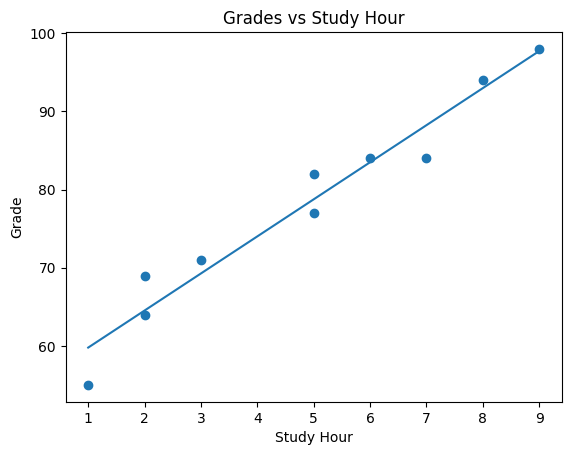

In [50]:
plt.scatter(x=hours,y=grades)
plt.title("Grades vs Study Hour")
plt.xlabel("Study Hour")
plt.ylabel("Grade")
plt.plot(x_line,y_line)
plt.show()

In [52]:
y_hat = hours_model.predict(X=X)
y_hat

array([64.52071006, 97.71893491, 78.74852071, 78.74852071, 69.26331361,
       88.23372781, 59.77810651, 92.97633136, 83.49112426, 64.52071006])

In [55]:
residuals = y - y_hat
residuals

0    4.479290
1    0.281065
2    3.251479
3   -1.748521
4    1.736686
5   -4.233728
6   -4.778107
7    1.023669
8    0.508876
9   -0.520710
Name: Grade on Exam, dtype: float64

In [61]:
## Sum of Squares Risiduals
ss_res = np.sum(residuals ** 2)
## Sum of Squares total
ss_tot = np.sum((y - y.mean()) ** 2)

In [64]:
rmse = np.sqrt(np.mean(residuals ** 2))
rmse

np.float64(2.812850898557333)

In [62]:
r2 = 1 - (ss_res/ss_tot) 

r2

np.float64(0.9505368205956815)

In [ ]:
import pandas as pd
import numpy as np

ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [5]:
channel_results = []

for channel in ["tv", "radio", "social_media"]:
    X_channel = ads[[channel]]
    y_sales = ads["sales"]

    channel_model = LinearRegression()
    channel_model.fit(X_channel, y_sales)

    y_hat = channel_model.predict(X_channel)

    r2_channel = 1 - np.sum((y_sales - y_hat) ** 2) / np.sum((y_sales - y_sales.mean()) ** 2)
    rmse_channel = np.sqrt(np.mean((y_sales - y_hat) ** 2))

    channel_results.append({
        "channel": channel,
        "intercept": channel_model.intercept_,
        "slope": channel_model.coef_[0],
        "r_squared": r2_channel,
        "rmse": rmse_channel
    })

pd.DataFrame(channel_results).round(4)

,channel,intercept,slope,r_squared,rmse
0,tv,-132.4925,3.5615,0.9990,2948.5897
1,radio,40586.8007,8.3616,0.7545,46081.4060
2,social_media,118672.5717,22.1879,0.2782,79019.9030


In [8]:
import plotly.express as px

# Compute correlation
corr = ads[["tv", "radio", "social_media", "sales"]].corr().round(3)
corr


,tv,radio,social_media,sales
tv,1.000,0.869,0.528,0.999
radio,0.869,1.000,0.606,0.869
social_media,0.528,0.606,1.000,0.527
sales,0.999,0.869,0.527,1.000


In [9]:
# Plot
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
)

# Improve layout
fig.update_layout(
    title="Correlation Matrix",
    xaxis_title="",
    yaxis_title="",
)

fig.show()

$$Y = \beta_0 + \beta_{tv} X_{tv} + \beta_{radio} X_r + \beta_{sm} X_s$$

In [12]:
X_multi_num = ads[["tv", "radio", "social_media"]]
y_sales = ads["sales"]

multi_num_model = LinearRegression()
multi_num_model.fit(X_multi_num, y_sales)

y_hat_multi_num = multi_num_model.predict(X_multi_num)


In [16]:
list(multi_num_model.coef_)

[np.float64(3.562569626537576),
 np.float64(-0.003970380612866524),
 np.float64(0.004963957746853112)]

['tv', 'radio', 'social_media']

In [18]:
['intercept'] + list(X_multi_num.columns)

['intercept', 'tv', 'radio', 'social_media']

In [21]:
type(multi_num_model.coef_)

numpy.ndarray

In [15]:

multi_num_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi_num.columns),
    "coefficient": [multi_num_model.intercept_] + list(multi_num_model.coef_)
}).round(4)

multi_num_results

,feature,coefficient
0,intercept,-133.9630
1,tv,3.5626
2,radio,-0.0040
3,social_media,0.0050


$$Y = \beta_0 + \beta_{tv} X_{tv} + \beta_{radio} X_r + \beta_{sm} X_s$$

In [22]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)

In [33]:

X_multi = pd.get_dummies(
    ads[["tv", "radio", "social_media", "influencer"]],
    drop_first=True,

    dtype=int
)


X_multi


,tv,radio,social_media,influencer_Macro,influencer_Micro,influencer_Nano
0,16000.0,6566.23,2907.98,0,0,0
1,13000.0,9237.76,2409.57,0,0,0
2,41000.0,15886.45,2913.41,0,0,0
3,83000.0,30020.03,6922.30,0,0,0
4,15000.0,8437.41,1406.00,0,1,0
...,...,...,...,...,...,...
4541,26000.0,4472.36,717.09,0,1,0
4542,71000.0,20610.69,6545.57,0,0,1
4543,44000.0,19800.07,5096.19,0,1,0
4544,71000.0,17534.64,1940.87,1,0,0


In [ ]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)

X_multi = pd.get_dummies(
    ads[["tv", "radio", "social_media", "influencer"]],
    drop_first=True, # չենք մոռանում
    dtype=int
)

multi_model = LinearRegression()
multi_model.fit(X_multi, y_sales)

y_hat_multi = multi_model.predict(X_multi)

multi_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi.columns),
    "coefficient": [multi_model.intercept_] + list(multi_model.coef_)
}).round(4)

multi_r2 = 1 - np.sum((y_sales - y_hat_multi) ** 2) / np.sum((y_sales - y_sales.mean()) ** 2)
multi_rmse = np.sqrt(np.mean((y_sales - y_hat_multi) ** 2))

multi_results
print(f"R-squared: {multi_r2:.4f}")
print(f"RMSE: {multi_rmse:.2f}")

R-squared: 0.9990
RMSE: 2948.31


In [37]:
multi_results

,feature,coefficient
0,intercept,-91.7009
1,tv,3.5626
2,radio,-0.0039
3,social_media,0.0045
4,influencer_Macro,-11.6028
5,influencer_Micro,-68.4840
6,influencer_Nano,-85.5007


$$Y = \beta_0 + \beta_{tv} X_{tv} + \beta_{radio} X_r + \beta_{sm} X_s + \beta_{...} X_{...}$$

## Time Series

In [4]:
import pandas as pd
from os.path import join
import glob
import shutil
import os
PATH = '../data/regression/time_series'

In [17]:
csv_files = [i for i in glob.glob("../data/regression/time_series/*.csv")]
csv_files

['../data/regression/time_series/gold_prices_2026_apr_june.csv',
 '../data/regression/time_series/gold_prices_2022_2026.csv']

In [ ]:
# l = []
# for i in csv_files:
#     df = pd.read_csv(i)
#     l.append(df)

#     shutil.move(src = i, dst = "../data/regression/time_series/loaded/")


# df = pd.concat(l)


# df.to_csv('../data/regression/time_series/gold_prices_2022_2026.csv', index = False)



In [21]:
df= pd.read_csv('../data/regression/time_series/gold_prices_2022_2026.csv', parse_dates=['Date'])
df.head()

,Date,Open,High,Low,Close
0,2026-06-03,"4,520.00","4,525.10","4,454.00","4,466.90"
1,2026-06-02,"4,515.80","4,571.30","4,492.30","4,519.90"
2,2026-06-01,"4,575.20","4,577.30","4,476.00","4,506.30"
3,2026-05-29,"4,527.60","4,627.10","4,519.50","4,593.00"
4,2026-05-28,"4,488.00","4,547.10","4,395.60","4,532.40"


In [ ]:
df.dtypes

# object

Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object

In [ ]:
df['Close'] = df['Close'].str.replace(",","",regex = False).str.strip()

df['Close'] = pd.to_numeric(df['Close'])



Date         datetime64[us]
Open                    str
High                    str
Low                     str
Close               float64
CloseTest           float64
dtype: object

## Mini Homework

Try to create a loop which will the exacltly thee same for  `Open`, `High`, `Low`

In [33]:
## Put you code here

In [32]:
df.head()

,Date,Open,High,Low,Close
0,2026-06-03,"4,520.00","4,525.10","4,454.00",4466.9
1,2026-06-02,"4,515.80","4,571.30","4,492.30",4519.9
2,2026-06-01,"4,575.20","4,577.30","4,476.00",4506.3
3,2026-05-29,"4,527.60","4,627.10","4,519.50",4593.0
4,2026-05-28,"4,488.00","4,547.10","4,395.60",4532.4


In [34]:
df.shape

(1035, 5)

In [36]:
df = df.sort_values(by='Date')

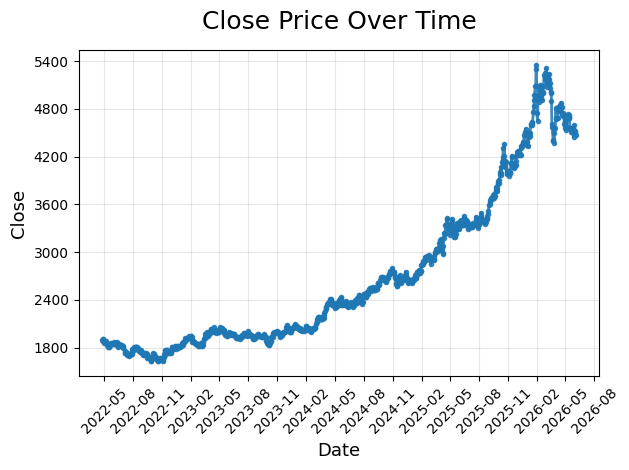

In [37]:
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


plt.plot(
    df["Date"],
    df["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
df.reset_index(inplace=True)

In [43]:
df.drop(columns='index',inplace=True)


,Date,Open,High,Low,Close
1030,2026-05-28,"4,488.00","4,547.10","4,395.60",4532.4
1031,2026-05-29,"4,527.60","4,627.10","4,519.50",4593.0
1032,2026-06-01,"4,575.20","4,577.30","4,476.00",4506.3
1033,2026-06-02,"4,515.80","4,571.30","4,492.30",4519.9
1034,2026-06-03,"4,520.00","4,525.10","4,454.00",4466.9


In [46]:
df.tail()


,Date,Open,High,Low,Close
1030,2026-05-28,"4,488.00","4,547.10","4,395.60",4532.4
1031,2026-05-29,"4,527.60","4,627.10","4,519.50",4593.0
1032,2026-06-01,"4,575.20","4,577.30","4,476.00",4506.3
1033,2026-06-02,"4,515.80","4,571.30","4,492.30",4519.9
1034,2026-06-03,"4,520.00","4,525.10","4,454.00",4466.9


In [ ]:
import numpy as np



array([   1,    2,    3, ..., 1033, 1034, 1035], shape=(1035,))

In [53]:
df['time_index'] = np.arange(1,len(df)+1)

df.head()

,Date,Open,High,Low,Close,time_index
0,2022-04-25,"1,931.90","1,935.50","1,891.80",1896.0,1
1,2022-04-26,"1,899.80","1,912.20","1,896.30",1904.1,2
2,2022-04-27,"1,907.40","1,908.10","1,881.60",1888.7,3
3,2022-04-28,"1,886.80","1,897.80","1,870.90",1891.3,4
4,2022-04-29,"1,895.80","1,921.30","1,893.50",1911.7,5


$$\text{Close} = \beta_0 + \beta_1 \text{time index}$$

In [59]:
from sklearn.linear_model import LinearRegression

trend_model = LinearRegression()
X = df[['time_index']]
y = df['Close']

trend_model.fit(X=X,y = y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_hat = trend_model.predict(X) #! Change  

In [63]:
r2_score(y,y_hat)

0.8375868032011492

In [65]:
root_mean_squared_error(y_hat,y)

396.0682658329888

## Homework

- **PART 1:**
  1. Split the data into two parts (name it `train` and `test`)
  2. `train` <= `'2026-01-01`'
  3. `test` > `'2026-01-01`'
  4. evaluate the model using `R2_Squared` and `RMSE`
  5. do not forget to evaluate for testing

- **PART 2:**
  1. Download jun 4 and jun 5
  2. `read_csv()`
  3. `fit.predict()`


In [67]:
pd.read_csv()
# fix Close in order to make numeric
np.arange(start = 1036,stop=1038)

array([1036, 1037])

In [69]:
from statsmodels.tsa.arima.model import ARIMA

df = df.set_index('Date').asfreq("B")

df.head()

,Open,High,Low,Close,time_index
Date,,,,,
2022-04-25,"1,931.90","1,935.50","1,891.80",1896.0,1.0
2022-04-26,"1,899.80","1,912.20","1,896.30",1904.1,2.0
2022-04-27,"1,907.40","1,908.10","1,881.60",1888.7,3.0
2022-04-28,"1,886.80","1,897.80","1,870.90",1891.3,4.0
2022-04-29,"1,895.80","1,921.30","1,893.50",1911.7,5.0


In [ ]:
arima_model = ARIMA(df['Close'],order=(1,1,1),) # x, y, քանի որ `date` սյունը դարձրել ենք ինդեքս արդյունքում x և y արժեքները տրված են order = (p,dq)

arima_fit = arima_model.fit()

In [74]:
arima_forecast = arima_fit.forecast(steps=2)
arima_forecast

2026-06-04    4470.673619
2026-06-05    4473.046782
Freq: B, Name: predicted_mean, dtype: float64

In [ ]:
df['Close']


Date
2022-04-25    1896.0
2022-04-26    1904.1
2022-04-27    1888.7
2022-04-28    1891.3
2022-04-29    1911.7
               ...  
2026-05-28    4532.4
2026-05-29    4593.0
2026-06-01    4506.3
2026-06-02    4519.9
2026-06-03    4466.9
Freq: B, Name: Close, Length: 1073, dtype: float64

In [79]:
from prophet import Prophet

df_prophet = df.reset_index().rename(columns={"Date": "ds", "Close": "y"})
df_prophet.head()

,ds,Open,High,Low,y,time_index
0,2022-04-25,"1,931.90","1,935.50","1,891.80",1896.0,1.0
1,2022-04-26,"1,899.80","1,912.20","1,896.30",1904.1,2.0
2,2022-04-27,"1,907.40","1,908.10","1,881.60",1888.7,3.0
3,2022-04-28,"1,886.80","1,897.80","1,870.90",1891.3,4.0
4,2022-04-29,"1,895.80","1,921.30","1,893.50",1911.7,5.0


In [85]:

prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=3, freq="B")

forecast = prophet_model.predict(future)



20:54:56 - cmdstanpy - INFO - Chain [1] start processing
20:54:56 - cmdstanpy - INFO - Chain [1] done processing


In [81]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

,ds,yhat,yhat_lower,yhat_upper
1073,2026-06-04,4714.298252,4599.799143,4825.144137
1074,2026-06-05,4714.847866,4607.495989,4834.059531
1075,2026-06-08,4713.251150,4587.654473,4825.978496


Text(0.5, 36.72222222222221, 'Date')

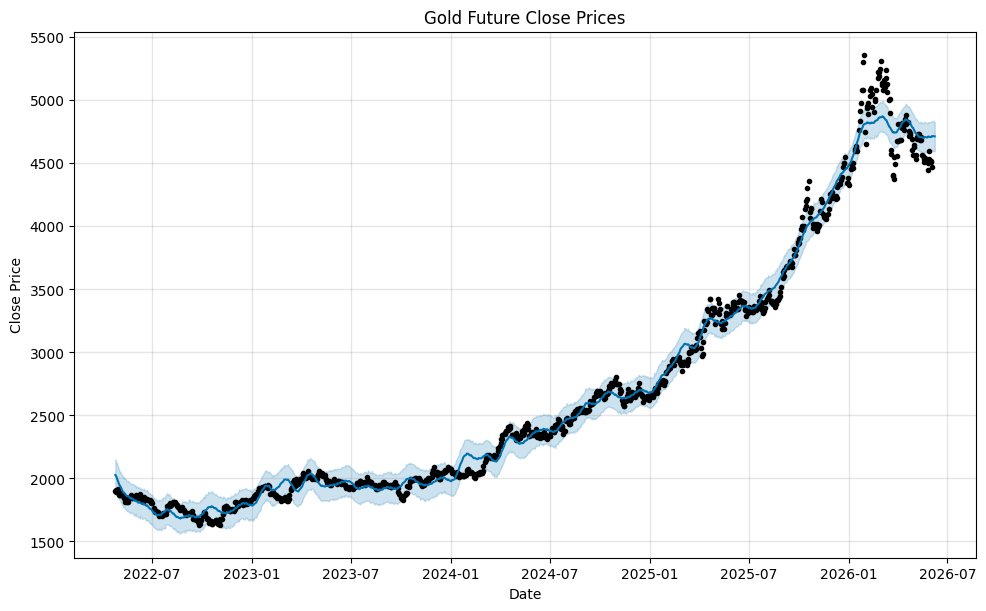

In [92]:
prophet_model.plot(forecast)
plt.title('Gold Future Close Prices')
plt.ylabel('Close Price')
plt.xlabel('Date')

In [84]:
arima_forecast

2026-06-04    4470.673619
2026-06-05    4473.046782
Freq: B, Name: predicted_mean, dtype: float64

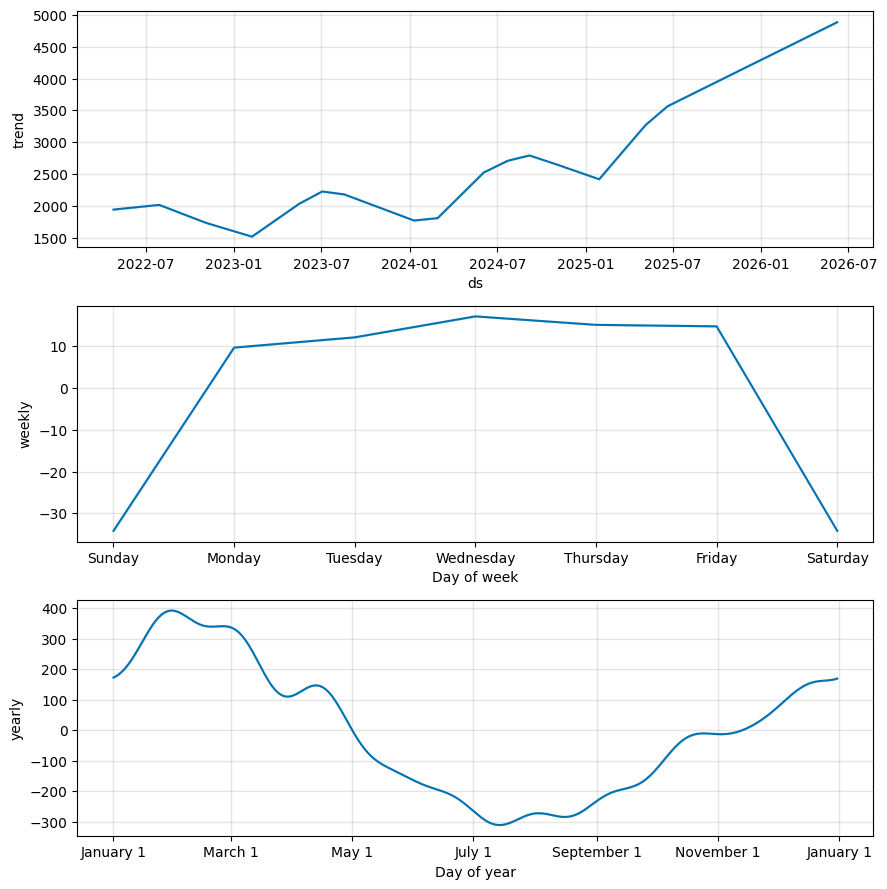

In [93]:
prophet_model.plot_components(forecast)
plt.show()